<a href="https://colab.research.google.com/github/lucasdp5/proyectods/blob/main/ProyectoDS_ParteII_Perea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto: Detección de Anomalías - Unidad Generadora 02

En el contexto actual de operación de centrales hidroeléctricas, garantizar la confiabilidad de los generadores es clave para mantener la disponibilidad del servicio y optimizar los costos de mantenimiento. Este proyecto está dirigido a equipos de ingeniería de mantenimiento con el objetivo de anticipar fallas en componentes críticos.

La operación confiable de un generador depende del adecuado funcionamiento de componentes críticos como el cojinete axial, cuya falla puede implicar paradas no programadas que conllevan un alto impacto económico.

Este proyecto tiene como propósito analizar el comportamiento operativo de la unidad generadora ADT02 de una central hidroeléctrica, a partir del procesamiento de datos históricos provenientes de sensores instalados en la máquina. El foco está puesto en variables clave como la potencia activa, el caudal turbinado, la apertura del distribuidor, las temperaturas del cojinete axial (aceite, metal y agua) y las vibraciones.

El análisis busca identificar relaciones significativas entre estas variables que permitan interpretar fenómenos relevantes, como el rendimiento energético de la unidad o la detección temprana de condiciones anómalas en el sistema de refrigeración del cojinete axial.

# Preguntas e hipótesis

**Preguntas de interés**

- ¿Existe relación entre la potencia generada y el caudal turbinado?
- ¿Como se comportan las vibraciones en relación con la temperatura del cojinete?
- ¿Qué efecto tiene la apertura del distribuidor sobre la potencia y la temperatura del cojinete?
- ¿Las temperaturas del cojinete (metal y aceite) están correlacionadas?
- ¿Hay diferencias significativas de temperatura entre los distintos sensores del cojinete (x1 a x12)?
- ¿La eficiencia del sistema de enfriamiento (entrada vs salida de agua) varía en función del esfuerzo operativo?

**Hipótesis**

- H1: A mayor apertura del distribuidor, mayor potencia generada y mayor temperatura en los cojinetes.
- H2: Las temperaturas del metal y del aceite del cojinete axial se comportan de forma sincronizada (alta correlación).
- H3: Si el sistema de enfriamiento es eficiente, la diferencia entre la temperatura de entrada y salida del agua debe mantenerse constante.
- H4: A mayor incremento de vibraciones, mayor temperatura de cojinetes.

In [2]:
!pip install missingno

In [51]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import math

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

In [6]:
# Carga del dataset
github_csv_url = 'https://raw.githubusercontent.com/lucasdp5/proyectods/refs/heads/main/dataset_gen2.csv'

try:
    df = pd.read_csv(github_csv_url, parse_dates=['Timestamp'])
    print("Datos cargados desde GitHub")
except Exception as e:
    print(f"Error cargando datos desde GitHub: {e}")

Datos cargados desde GitHub


Se inspecciona el DF para revisar, nombres de columnas, cantidad de filas y columnas e información general.

In [7]:
df.shape

(8113, 32)

In [8]:
display(df.columns)

Index(['Timestamp', 'Potencia activa ADT02', 'Caudal Turbinado',
       'Nivel de cota de embalse',
       'Temperatura aceite caliente cojinete axial',
       'Temperatura aceite frio cojinete axial',
       'Temperatura entrada agua enfriam. aceite',
       'Temperatura salida agua  enfriam. aceite',
       'Temperatura bobinado fase U', 'Temperatura bobinado fase V',
       'Temperatura bobinado fase W', 'Apertura Distribuidor',
       'Temperatura metal cojinete Axial x1',
       'Temperatura metal cojinete Axial x2',
       'Temperatura metal cojinete Axial x3',
       'Temperatura metal cojinete Axial x4',
       'Temperatura metal cojinete Axial x5',
       'Temperatura metal cojinete Axial x6',
       'Temperatura metal cojinete Axial x7',
       'Temperatura metal cojinete Axial x8',
       'Temperatura metal cojinete Axial x9',
       'Temperatura metal cojinete Axial x10',
       'Temperatura metal cojinete Axial x11',
       'Temperatura metal cojinete Axial x12', 'Vibracio

In [9]:
#Se obtiene información de cada columna
df.info()

#Se observa que salvo el Timestamp todos los valores son de tipo float, por lo que no es necesario convertir ningún valor para poder trabajarlos.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8113 entries, 0 to 8112
Data columns (total 32 columns):
 #   Column                                      Non-Null Count  Dtype              
---  ------                                      --------------  -----              
 0   Timestamp                                   8113 non-null   datetime64[ns, UTC]
 1   Potencia activa ADT02                       8110 non-null   float64            
 2   Caudal Turbinado                            8110 non-null   float64            
 3   Nivel de cota de embalse                    8110 non-null   float64            
 4   Temperatura aceite caliente cojinete axial  8110 non-null   float64            
 5   Temperatura aceite frio cojinete axial      8110 non-null   float64            
 6   Temperatura entrada agua enfriam. aceite    8110 non-null   float64            
 7   Temperatura salida agua  enfriam. aceite    8110 non-null   float64            
 8   Temperatura bobinado fase U           

In [10]:
display(df.head())

,Timestamp,Potencia activa ADT02,Caudal Turbinado,Nivel de cota de embalse,Temperatura aceite caliente cojinete axial,Temperatura aceite frio cojinete axial,Temperatura entrada agua enfriam. aceite,Temperatura salida agua enfriam. aceite,Temperatura bobinado fase U,Temperatura bobinado fase V,...,Temperatura metal cojinete Axial x11,Temperatura metal cojinete Axial x12,Vibracion absoluta superior X,Vibracion absoluta turbina X,Vibracion relativa inferior X,Vibracion relativa inferior Y,Vibracion relativa superior X,Vibracion relativa superior Y,Vibracion relativa turbina X,Vibracion relativa turbina Y
0,2024-07-01 03:00:00+00:00,-0.100243,0.0,1337.12,12.795834,11.711283,13.237692,21.15381,34.53576,34.414635,...,30.740421,30.700046,0.145982,0.155278,0.129989,0.184281,0.126116,0.128255,0.102553,0.061889
1,2024-07-01 03:30:00+00:00,-0.100243,0.0,1337.12,12.795834,11.711283,13.237692,21.15381,34.53576,34.414635,...,30.740421,30.700046,0.144642,0.153899,0.129104,0.155675,0.098157,0.127375,0.101658,0.061552
2,2024-07-01 04:00:00+00:00,-0.100243,0.0,1337.12,12.795834,11.711283,13.237692,21.15381,34.53576,34.414635,...,30.740421,30.700046,0.143302,0.152520,0.128219,0.137150,0.098100,0.126496,0.100762,0.061214
3,2024-07-01 04:30:00+00:00,-0.100243,0.0,1337.12,12.795834,11.711283,13.237692,21.15381,34.53576,34.414635,...,30.740421,30.700046,0.141961,0.151141,0.127333,0.118625,0.097557,0.125616,0.099867,0.060876
4,2024-07-01 05:00:00+00:00,-0.100243,0.0,1337.12,12.795834,11.711283,13.237692,21.15381,34.53576,34.414635,...,30.740421,30.700046,0.140621,0.149762,0.126448,0.116289,0.097014,0.124737,0.098971,0.060538


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Potencia activa ADT02,8110.0,17.482574,28.253986,-0.165472,-0.126335,-0.100243,57.873817,71.936840
Caudal Turbinado,8110.0,16.136416,25.924869,-0.111792,0.000000,0.000000,52.060326,69.357490
Nivel de cota de embalse,8110.0,1335.138580,1.852592,1300.000000,1333.950000,1334.695000,1336.630000,1338.150000
Temperatura aceite caliente cojinete axial,8110.0,23.367033,12.957150,9.383119,13.639362,16.531492,39.976406,47.272950
Temperatura aceite frio cojinete axial,8110.0,16.602385,5.740888,8.501669,11.831784,13.800051,21.677350,29.208170
Temperatura entrada agua enfriam. aceite,8110.0,12.981320,3.441044,6.418277,11.028422,12.755667,15.005083,21.516266
Temperatura salida agua enfriam. aceite,8110.0,17.145497,5.657531,5.697103,12.434310,17.214352,21.153810,31.749807
Temperatura bobinado fase U,8110.0,43.432277,17.299594,10.827587,31.759901,43.508278,58.693024,74.054770
Temperatura bobinado fase V,8110.0,43.416667,17.711594,10.385730,31.426811,43.083228,59.303394,75.241000
Temperatura bobinado fase W,8110.0,45.996784,18.388320,12.273642,33.415321,45.248928,62.680775,79.331436


# Data Wrangling

In [12]:
#Se renombran las columnas de acuerdo con las mejores prácticas
df.columns = (
    df.columns
    .str.strip()                      # quitar espacios al principio y al final
    .str.lower()                     # pasar todo a minúscula
    .str.replace(' ', '_')          # reemplazar espacios por guiones bajos
    .str.replace(r'[^\w\s]', '', regex=True)  # eliminar caracteres especiales
)

In [13]:
#Valores duplicados
df.duplicated().sum()

np.int64(0)

Se observa que no hay valores duplicados, por lo tanto no se toma ninguna acción en relación a esto.

149


<Axes: >

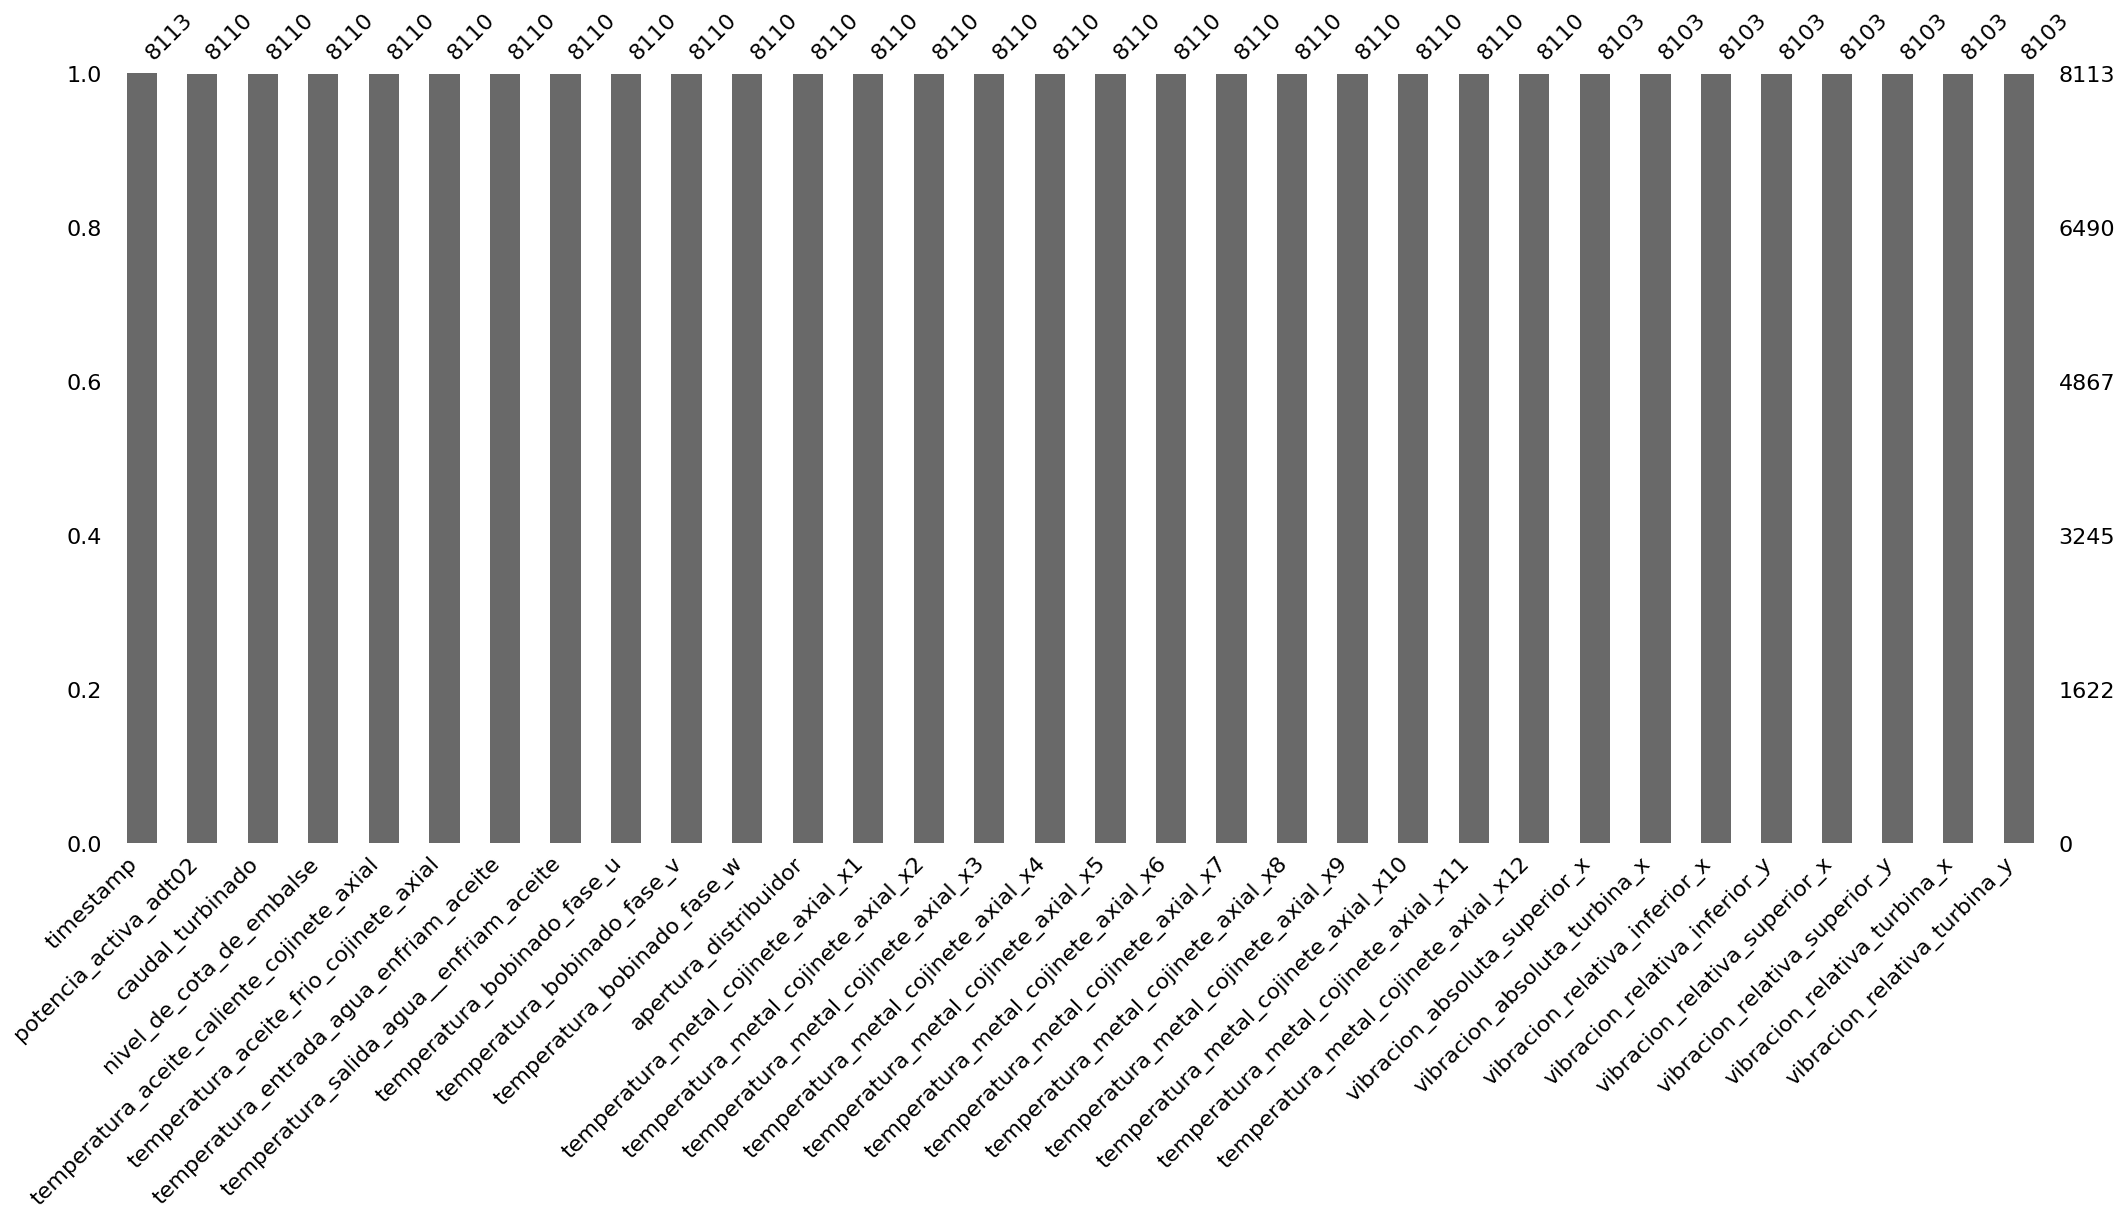

In [14]:
#Valores nulos
nulos = df.isnull().sum().sum()
print(nulos)
msno.bar(df)

Debido a la baja cantidad de valores nulos se decide elimininarlos porque no altera el conjunto de datos.

In [15]:
#Se eliminan los nulos
df.dropna(inplace=True)
#Se observa el resultado
df.shape

(8100, 32)

Se observa un total de 8100 filas de 8113 que tenía originalmente.

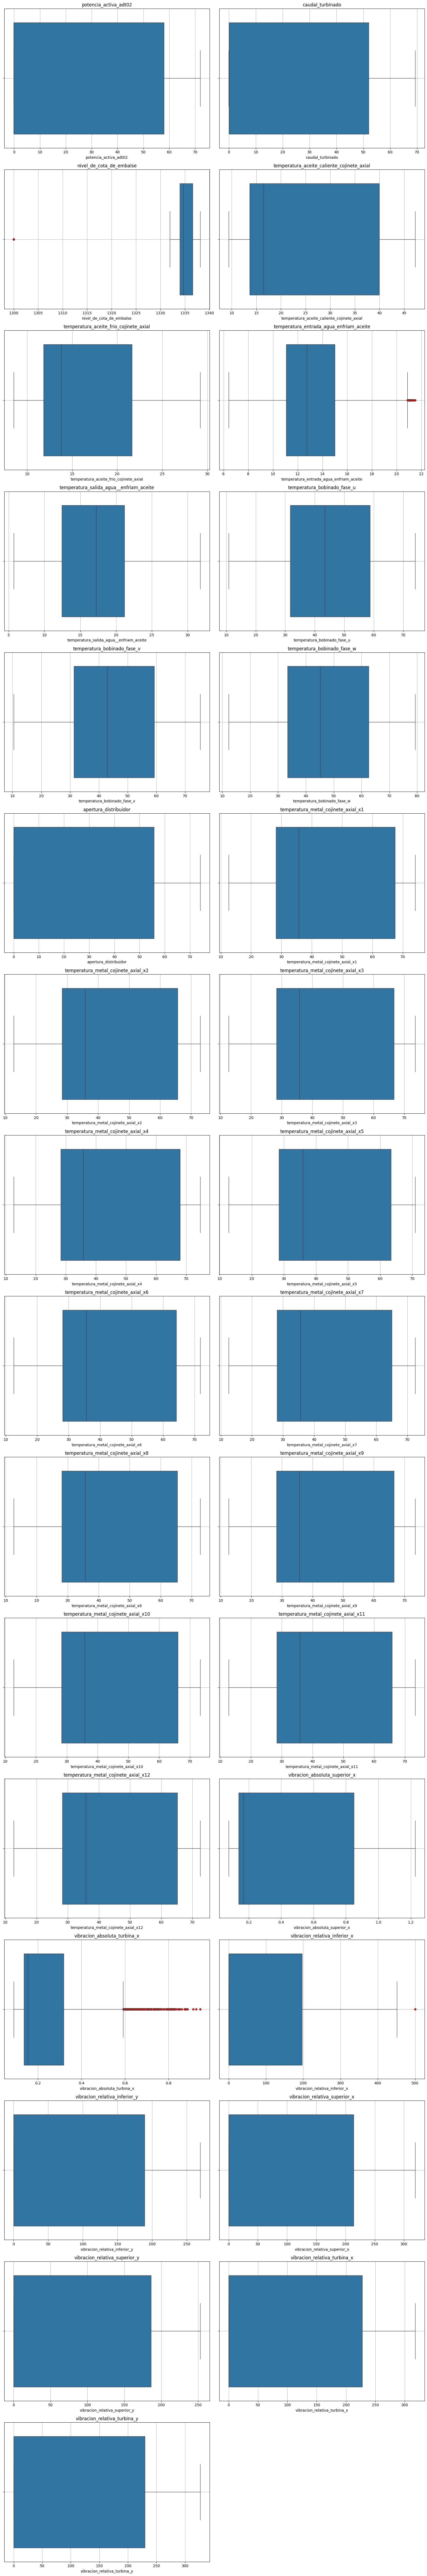

In [16]:
#Revisión de outliers
def ver_boxplots(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 2
    n_rows = math.ceil(len(numeric_cols) / n_cols)

    plt.figure(figsize=(16, 6 * n_rows))

    flier_props = dict(marker='o', markerfacecolor='red', markersize=5, linestyle='none')

    for i, column in enumerate(numeric_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.boxplot(x=df[column], orient="y",flierprops=flier_props)
        plt.title(f'{column}')
        plt.grid(True)
        plt.tight_layout()

    plt.show()

ver_boxplots(df)

Se identifica que hay outlier en la medición de nivel de cota de embalse. Por ser una variable que no puede presentar ese tipo de escalones es muy probable que sea un error. Se procede a graficar una distribución de ésta.

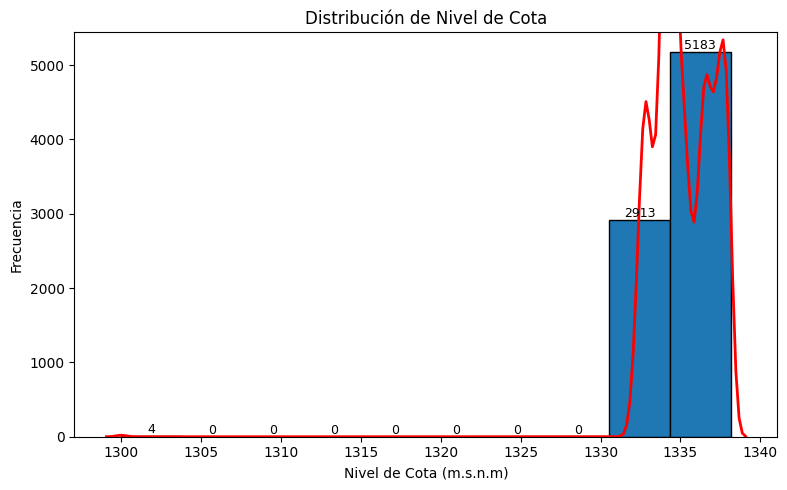

In [17]:
# Datos
x = df['nivel_de_cota_de_embalse']
# Crear figura y eje
fig, ax = plt.subplots(figsize=(8, 5))

# Histograma
counts, bins, bars = ax.hist(x, edgecolor='black')

# Etiquetas
ax.bar_label(bars, fmt='%d', fontsize=9)

# Calcular curva KDE
kde = sns.kdeplot(x, bw_adjust=1, ax=ax, color='red', linewidth=2)

# Escalar la KDE para que coincida con la escala del histograma
kde_y = kde.get_lines()[0].get_data()[1]
kde_x = kde.get_lines()[0].get_data()[0]

# Escalado manual: multiplicar la densidad por el área total del histograma
area = sum(np.diff(bins) * counts)
ax.lines[-1].set_ydata(kde_y * area)

# Títulos y etiquetas
ax.set_title('Distribución de Nivel de Cota')
ax.set_xlabel('Nivel de Cota (m.s.n.m)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Se procede a eliminar los registros donde el nivel es 1300. Para el caso de vibraciones y temperatura se decide mantener
porque puede representar algo importante.

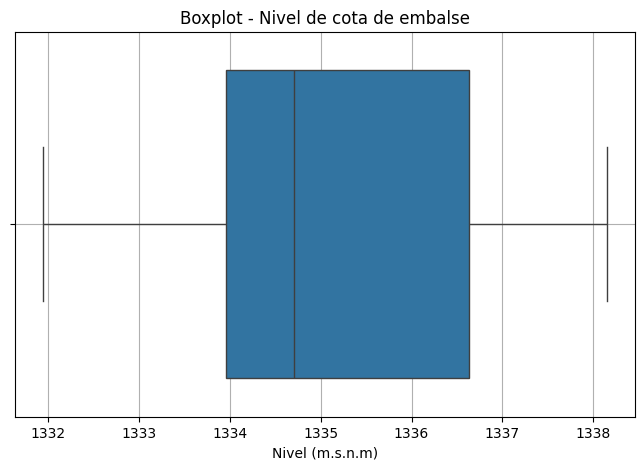

In [18]:
#Se elimina los registros para la cota 1300
df = df[df['nivel_de_cota_de_embalse'] != 1300]

#Se grafica nuevamente el boxplot para esta variable
flier_props = dict(marker='o', markerfacecolor='red', markersize=5, linestyle='none')

plt.figure(figsize=(8, 5))
sns.boxplot(x=df['nivel_de_cota_de_embalse'], orient="y", flierprops=flier_props)
plt.title("Boxplot - Nivel de cota de embalse")
plt.xlabel("Nivel (m.s.n.m)")
plt.grid(True)
plt.show()


Por otro lado, revisando el boxplot y el cuadro de las estadísticas descriptivas, se observa que hay una gran cantidad de valores de potencia activa que tienen valor negativo. Se procede a analizarlo.

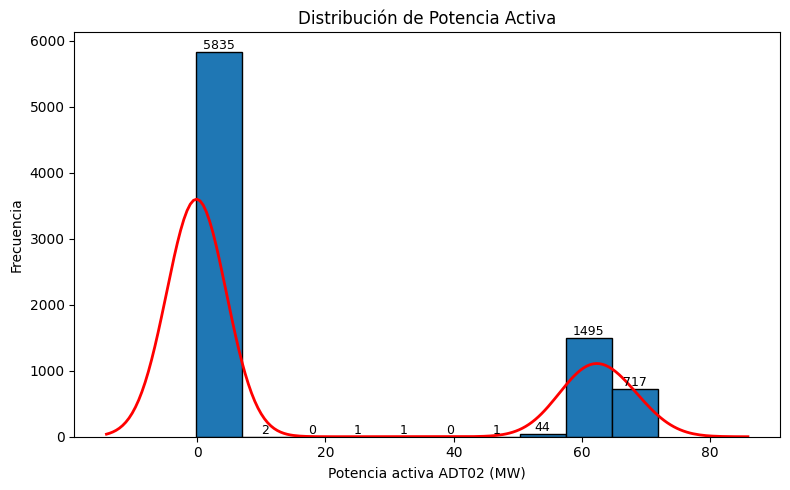

In [19]:
# Datos
x = df['potencia_activa_adt02']
# Crear figura y eje
fig, ax = plt.subplots(figsize=(8, 5))

# Histograma (sin normalizar)
counts, bins, bars = ax.hist(x, edgecolor='black')

# Etiquetas
ax.bar_label(bars, fmt='%d', fontsize=9)

# Calcular curva KDE
kde = sns.kdeplot(x, bw_adjust=1, ax=ax, color='red', linewidth=2)

# Escalar la KDE para que coincida con la escala del histograma
kde_y = kde.get_lines()[0].get_data()[1]
kde_x = kde.get_lines()[0].get_data()[0]

# Escalado manual: multiplicar la densidad por el área total del histograma
area = sum(np.diff(bins) * counts)
ax.lines[-1].set_ydata(kde_y * area)

# Títulos y etiquetas
ax.set_title('Distribución de Potencia Activa')
ax.set_xlabel('Potencia activa ADT02 (MW)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Se observa que hay existen valores que corresponden a un error de lectura cuando el generador está detenido. Se procede
a eliminar todos los registros cuando la potencia activa sea menor a 50.

In [20]:
#Se elimina los registros para potencia activa menor a 50
df = df[df["potencia_activa_adt02"] > 50]
df.shape

(2256, 32)

Se observa que se reduce drásticamente la cantidad de registros gracias a esta limpieza.

In [21]:
# Descripción del dataset luego de la limpieza realizada
df.describe().T

,count,mean,std,min,25%,50%,75%,max
potencia_activa_adt02,2256.0,62.658197,3.388226,54.312400,60.023059,61.904870,65.169500,71.936840
caudal_turbinado,2256.0,57.561396,3.540362,48.329440,54.817040,57.808398,60.569983,69.357490
nivel_de_cota_de_embalse,2256.0,1334.349699,1.496214,1331.940000,1333.037500,1334.060000,1335.220000,1338.090000
temperatura_aceite_caliente_cojinete_axial,2256.0,42.823818,2.984382,19.503935,41.403280,43.589237,44.196446,47.272950
temperatura_aceite_frio_cojinete_axial,2256.0,24.395662,2.464625,11.430114,22.472713,24.576912,25.623987,29.208170
temperatura_entrada_agua_enfriam_aceite,2256.0,9.929411,2.495729,6.418277,8.381476,9.062586,11.992473,14.563245
temperatura_salida_agua__enfriam_aceite,2256.0,11.908153,2.604932,6.498405,10.225061,11.068590,14.121388,19.865458
temperatura_bobinado_fase_u,2256.0,62.929194,6.625805,19.463768,58.693024,63.982895,68.621704,74.054770
temperatura_bobinado_fase_v,2256.0,63.646690,6.861020,18.981762,59.303394,64.715340,69.435530,75.241000
temperatura_bobinado_fase_w,2256.0,67.521236,7.092459,21.032999,62.965622,68.743774,73.482124,79.331436


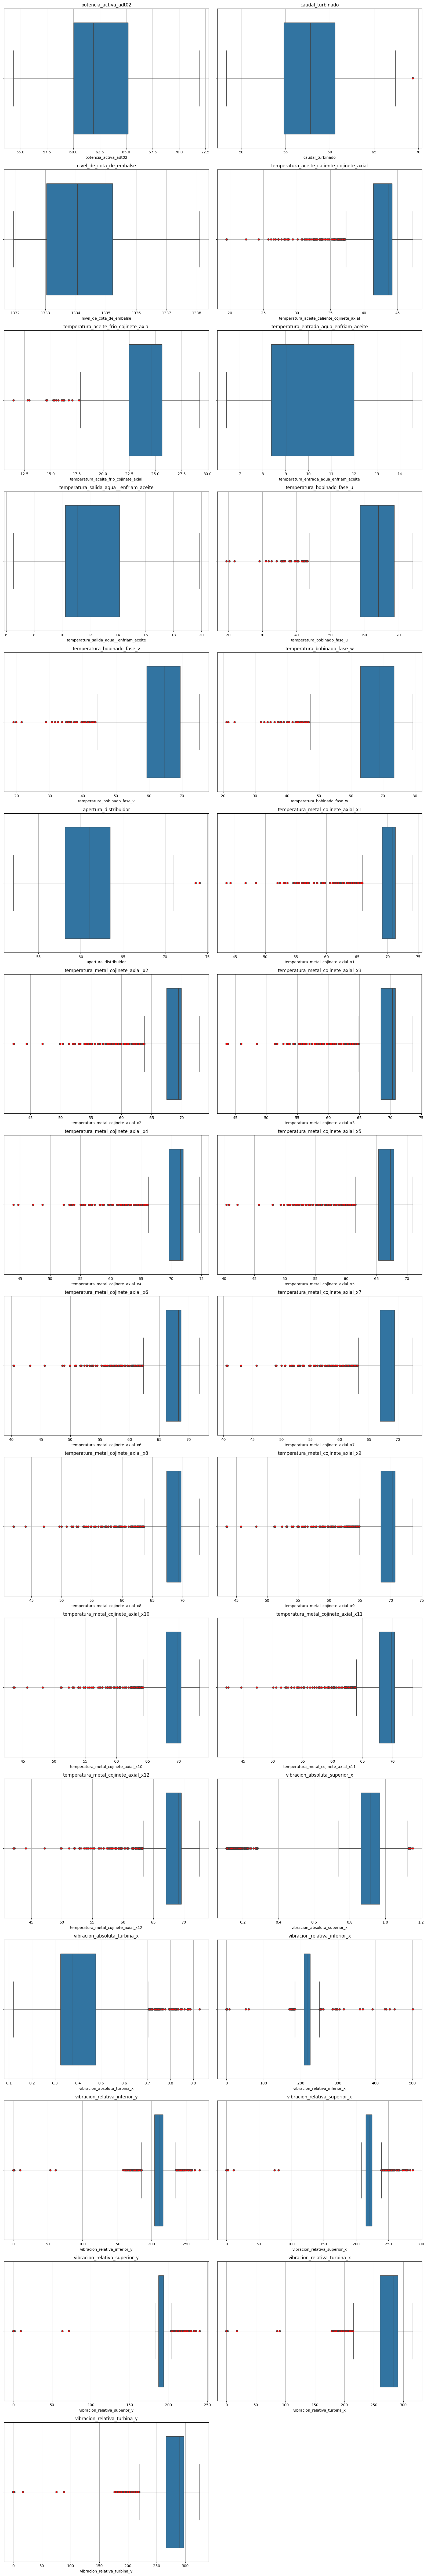

In [22]:
#Revisión de outliers
def ver_boxplots(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 2
    n_rows = math.ceil(len(numeric_cols) / n_cols)

    plt.figure(figsize=(16, 6 * n_rows))

    flier_props = dict(marker='o', markerfacecolor='red', markersize=5, linestyle='none')

    for i, column in enumerate(numeric_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.boxplot(x=df[column], orient="y",flierprops=flier_props)
        plt.title(f'{column}')
        plt.grid(True)
        plt.tight_layout()

    plt.show()

ver_boxplots(df)

# EDA (Análisis exploratorio de datos)

Se procede a graficar las distribuciones de todas las variables para revisar su comportamiento.

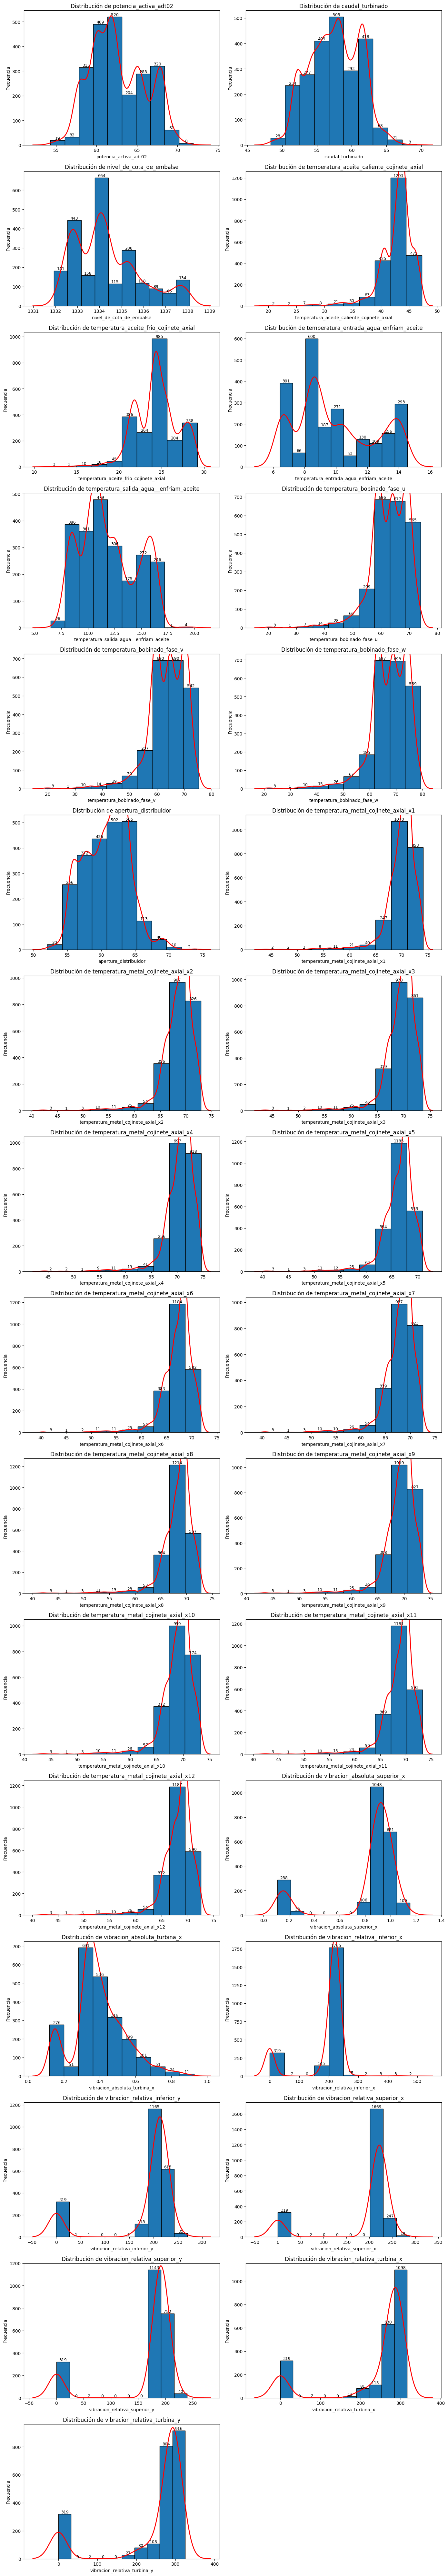

In [23]:
# Seleccionar variables numéricas
numeric_columns = df.select_dtypes(include=[np.number]).columns

# Definir número de columnas por fila
cols_per_row = 2
n_cols = cols_per_row
n_rows = int(np.ceil(len(numeric_columns) / cols_per_row))

# Crear figura general
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

# Iterar sobre variables
for i, col in enumerate(numeric_columns):
    ax = axes[i]
    x = df[col].dropna()

    # Histograma
    counts, bins, bars = ax.hist(x, edgecolor='black')
    ax.bar_label(bars, fmt='%d', fontsize=9)

    # KDE
    kde = sns.kdeplot(x, bw_adjust=1, ax=ax, color='red', linewidth=2)
    kde_y = kde.get_lines()[0].get_data()[1]
    kde_x = kde.get_lines()[0].get_data()[0]
    area = sum(np.diff(bins) * counts)
    ax.lines[-1].set_ydata(kde_y * area)

    # Etiquetas
    ax.set_title(f'Distribución de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')

# Eliminar ejes sobrantes si hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Se observa principalmente que todas las Temperaturas metal cojinete Axial xN tienen una dsitribución con sesgo hacia la izquierda y mantienen una forma muy similar entre ellas. Esto está asociado a la etapa de entrada en calor de los metales hasta que la máquina logra su régimen de operación.

P1: ¿Existe relación entre la potencia generada y el caudal turbinado?

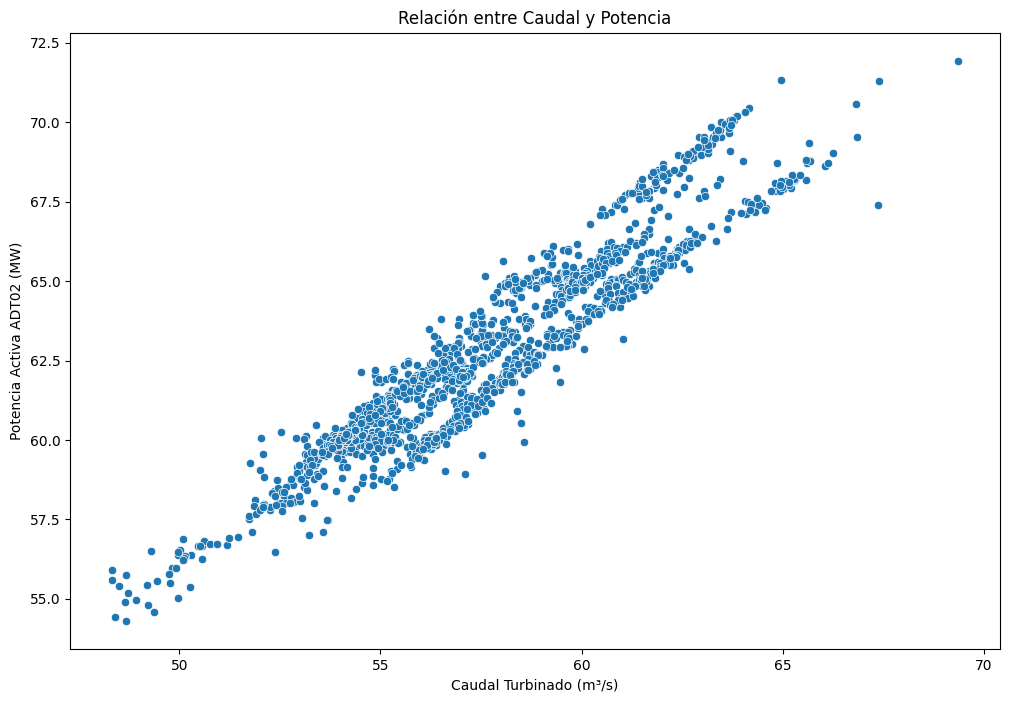

In [24]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='caudal_turbinado', y='potencia_activa_adt02')
plt.title('Relación entre Caudal y Potencia')
plt.xlabel('Caudal Turbinado (m³/s)')
plt.ylabel('Potencia Activa ADT02 (MW)')
plt.show()

#df[['Caudal Turbinado', 'Potencia activa ADT02']].corr()


Se observa que efectivamente hay una relación directamente proporcional entre la potencia y caudal turbinado.

P2: ¿Como se comportan las vibraciones en relación con la temperatura del cojinete?

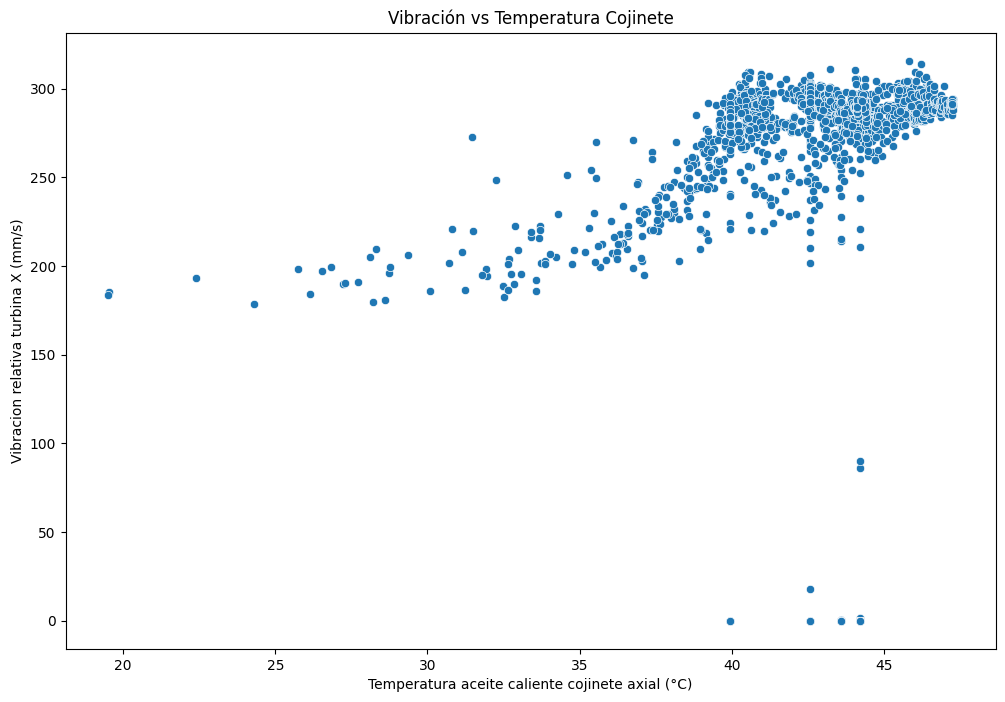

In [25]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='temperatura_aceite_caliente_cojinete_axial', y='vibracion_relativa_turbina_x')
plt.title('Vibración vs Temperatura Cojinete')
plt.xlabel('Temperatura aceite caliente cojinete axial (°C)')
plt.ylabel('Vibracion relativa turbina X (mm/s)')
plt.show()

A medida que la temperatura aumenta, la vibración también lo hace, pero se estabiliza alrededor de 250–300 mm/s cuando la temperatura pasa los 38 °C. Esto sugiere un límite físico o efecto de control automático.
Se observan algunos outliers, con:
- Temperaturas elevadas y vibraciones muy bajas (posible error).
- Temperaturas normales con vibraciones altas.

Esto responde a la **hipótesis 4** (A mayor incremento de vibraciones, mayor temperatura de cojinetes) indicando que no se cumple porque tiende a estabilizarse.

P3: ¿Qué efecto tiene la apertura del distribuidor sobre la potencia y la temperatura del cojinete?

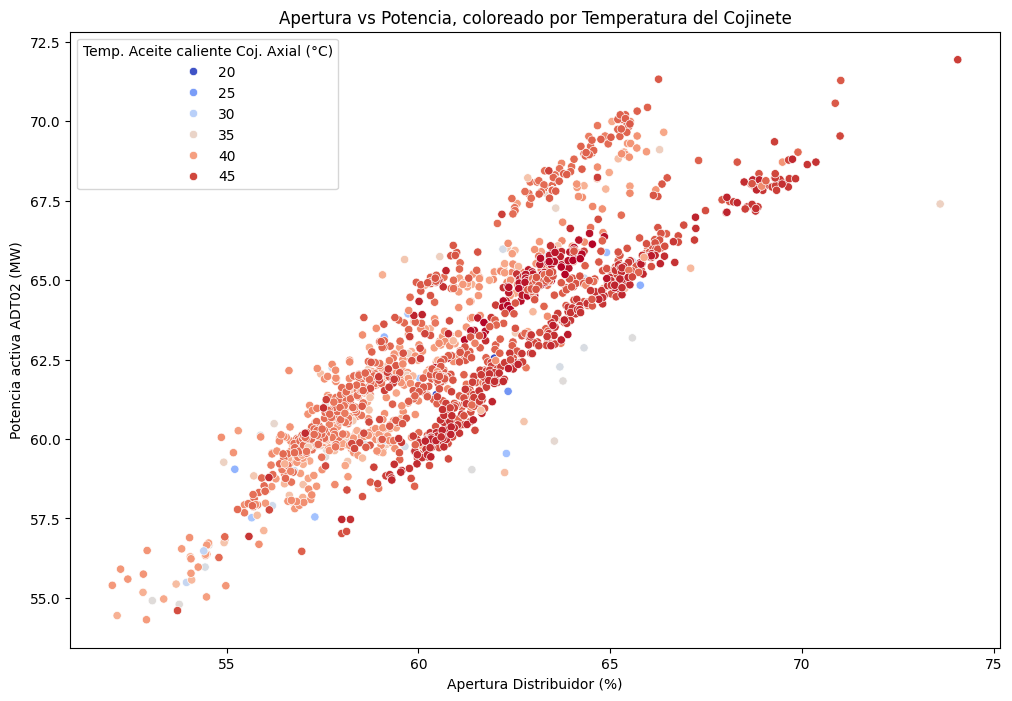

In [26]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x='apertura_distribuidor',
    y='potencia_activa_adt02',
    hue='temperatura_aceite_caliente_cojinete_axial',
    palette='coolwarm'
)
plt.title("Apertura vs Potencia, coloreado por Temperatura del Cojinete")
plt.xlabel('Apertura Distribuidor (%)')
plt.ylabel('Potencia activa ADT02 (MW)')
plt.legend(title='Temp. Aceite caliente Coj. Axial (°C)')
plt.show()

Se observa que al aumentar la apertura del distribuidor (básicamente que ingrese mas agua a la turbina), aumenta la potencia y por consiguiente la temperatura del cojinete. Para un generador con régimen de funcionamiento habitual entre los 60 y 65 MW, la temperatura del cojinete predomina el rango de los 40 a 45 °C. Para este caso no se observan outliers.

Esto responde a la **hipótesis 1** (A mayor apertura del distribuidor, mayor potencia generada y mayor temperatura en los cojinetes).

P4: ¿Las temperaturas del cojinete (metal y aceite) están correlacionadas?

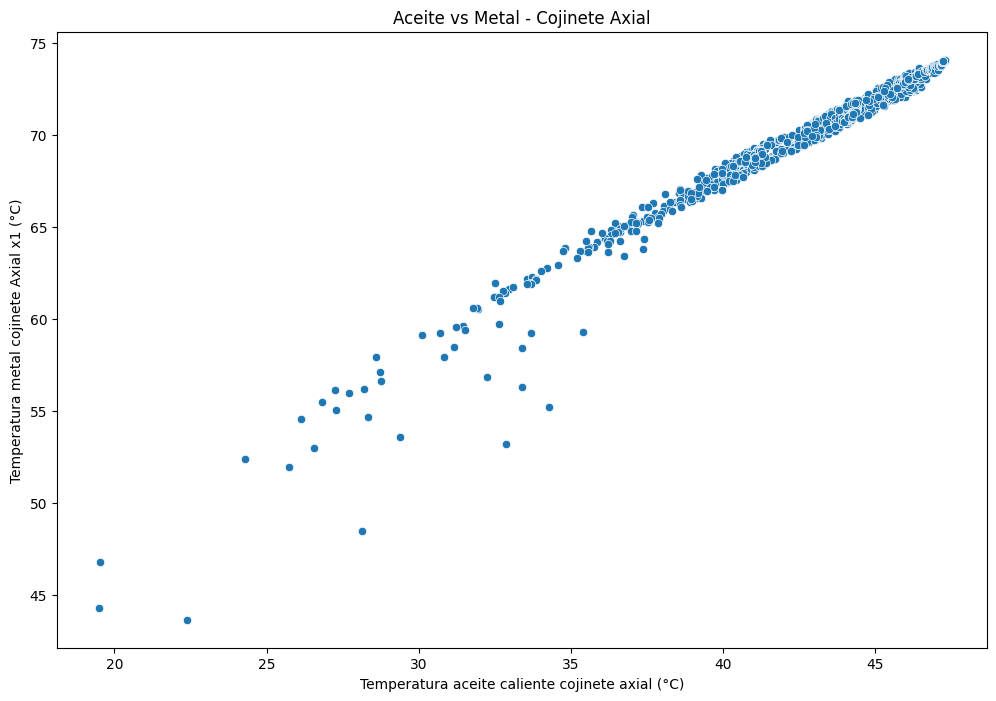

In [27]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='temperatura_aceite_caliente_cojinete_axial', y='temperatura_metal_cojinete_axial_x1')
plt.title('Aceite vs Metal - Cojinete Axial')
plt.xlabel('Temperatura aceite caliente cojinete axial (°C)')
plt.ylabel('Temperatura metal cojinete Axial x1 (°C)')
plt.show()

#df[['Temperatura aceite caliente cojinete axial', 'Temperatura metal cojinete Axial x1']].corr()

Esto sugiere que ambas variables están altamente correlacionadas. Mas adelante, en la matriz de correlación, se podrá ver este comportamiento
con cada una de las mediciones que se realizan en el metal del cojinete axial desde x1 a x12.

Esta relación puede ser útil para diagnóstico predictivo:
- Si en algún momento la temperatura del metal sube sin que suba la del aceite, podría indicar problemas de lubricación o transferencia de calor defectuosa.

Además, este tipo de gráfico también puede servir como base para construir un modelo de regresión que estime la temperatura del metal en función del aceite.

Nuevamente se confirma la **hipótesis 2** (Las temperaturas del metal y del aceite del cojinete axial se comportan de forma sincronizada (alta correlación)).

P5: ¿Hay diferencias significativas de temperatura entre los distintos sensores del cojinete (x1 a x12)?

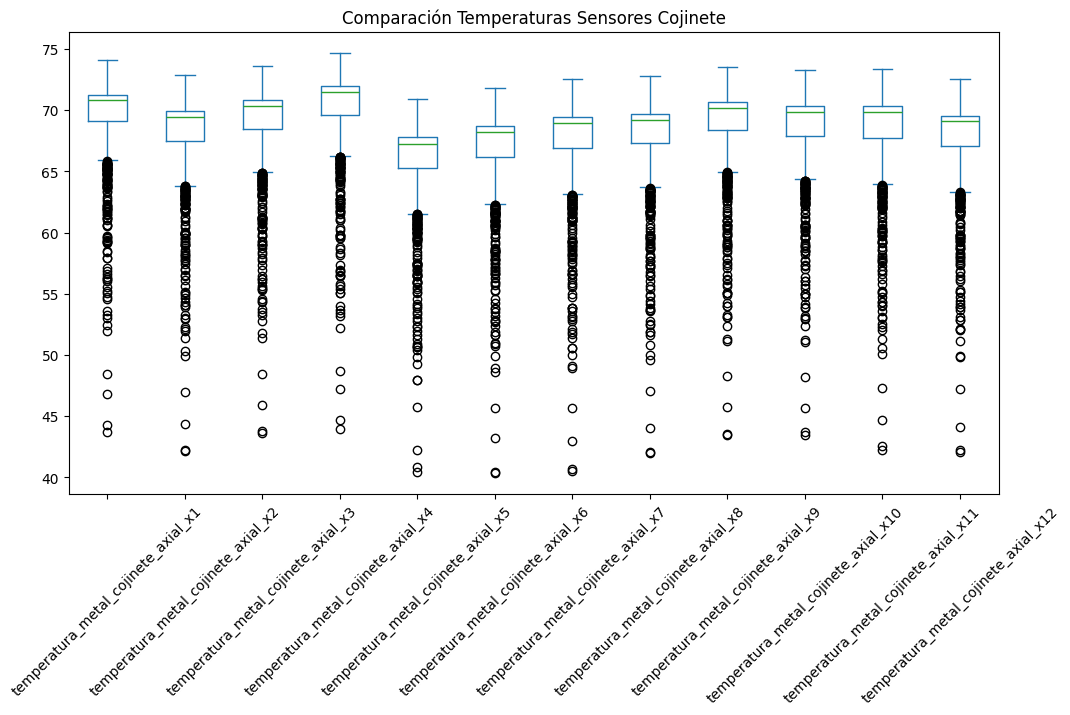

In [28]:
# Si tenés columnas tipo Temperatura x1, x2, ..., x12
cols_temp = [col for col in df.columns if "temperatura_metal_cojinete_axial_x" in col]
df[cols_temp].plot(kind='box', figsize=(12, 6), title='Comparación Temperaturas Sensores Cojinete')
plt.xticks(rotation=45)
plt.show()

Este gráfico permite visualizar la variabilidad en las mediciones de temperatura del cojinete axial para cada uno de los 12 sensores. Con esta información se puede
profundizar en la calidad de las mediciones y calibración de instrumentos si fuese necesaria.
Los outliers que se observan tienen que ver con la entrada en calor de la máquina.

P6: ¿La eficiencia del sistema de enfriamiento (entrada vs salida de agua) varía en función del esfuerzo operativo?

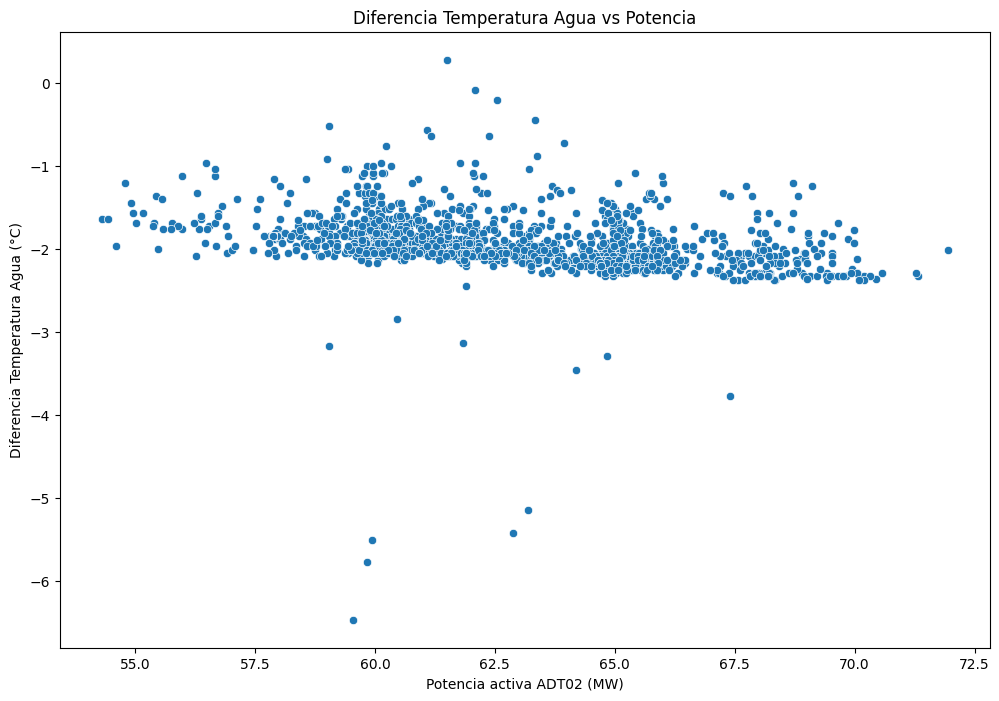

In [29]:
#Sistema de enfriamiento
plt.figure(figsize=(12, 8))
df['diferencia_temp_agua'] = df['temperatura_entrada_agua_enfriam_aceite'] - df['temperatura_salida_agua__enfriam_aceite']
sns.scatterplot(data=df, x='potencia_activa_adt02', y='diferencia_temp_agua')
plt.title('Diferencia Temperatura Agua vs Potencia')
plt.xlabel('Potencia activa ADT02 (MW)')
plt.ylabel('Diferencia Temperatura Agua (°C)')
plt.show()

Se observa que el sistema térmico mantiene el delta de temperatura constante independientemente de la carga. A primera vista sugiere que el sistema de enfriamiento esta dimensionado correctamente.
Hay varios puntos con diferencias muy negativas (hasta -6 °C) que se apartan fuertemente del grupo. Podrían indicar lecturas anómalas incorrectas.

Se podría pensar que responde satisfactoriamente a la **hipótesis 3** (Si el sistema de enfriamiento es eficiente, la diferencia entre la temperatura de entrada y salida del agua debe mantenerse constante.)

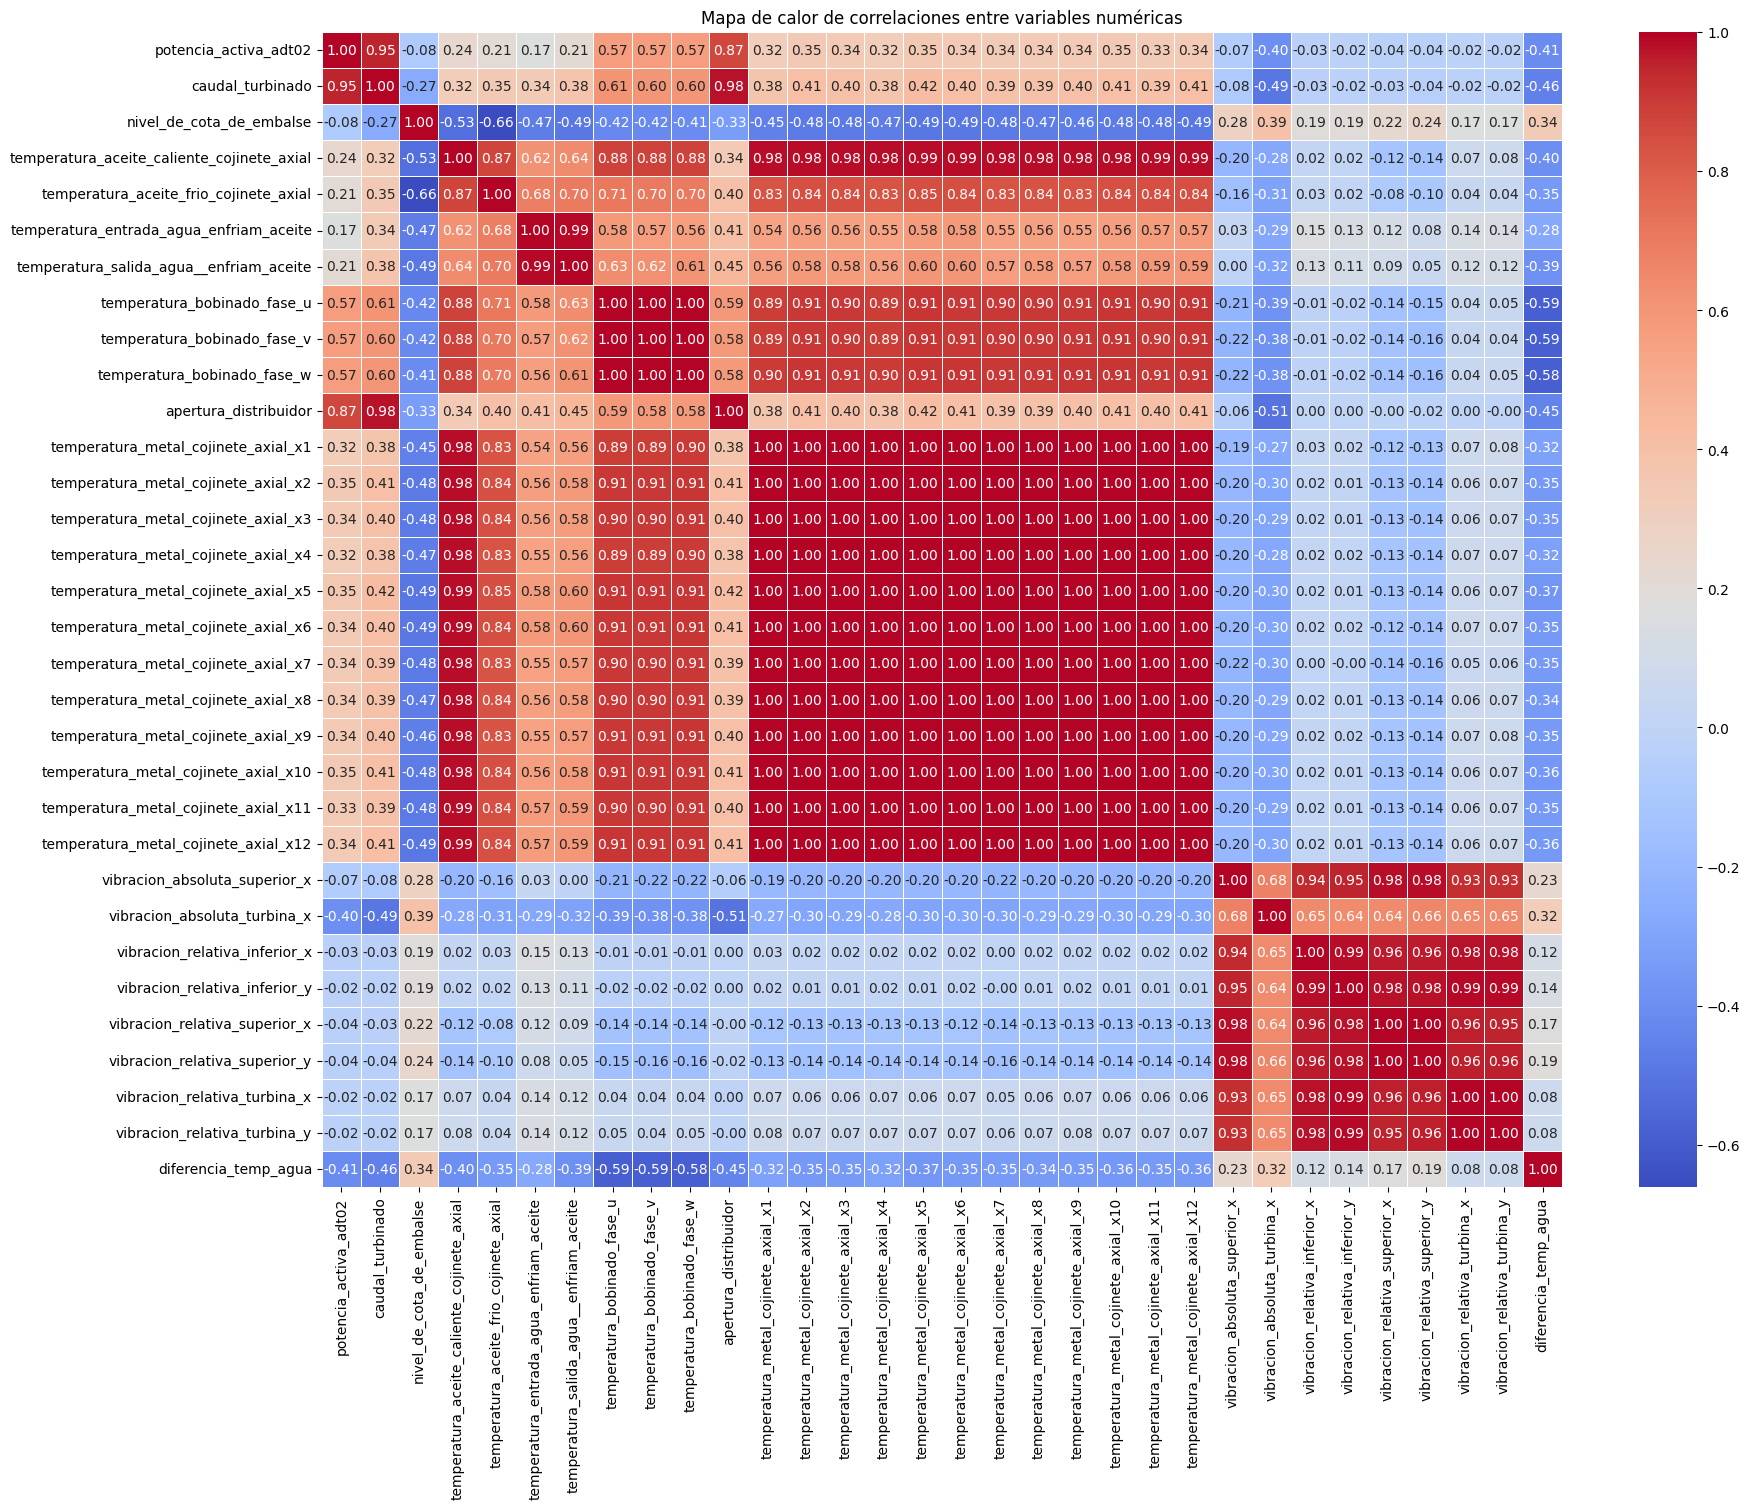

In [30]:
# Seleccionar solo las columnas numéricas para la matriz de correlación
df_numeric = df.select_dtypes(include=['number'])
# Calcular la matriz de correlación
correlation_matrix = df_numeric.corr()

plt.figure(figsize=(20, 15))
#sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Mapa de calor de correlaciones entre variables numéricas")
plt.show()

Finalmente se presenta un mapa de calor para presentar el grado correlación que tienen entre sí todas las variables y permiten complementar los comentarios indicados a los gráficos anteriores.

En esta gráfico se puede observar lo siguiente:
- Altísima correlación entre temperaturas de cojinetes axiales (> 0.99): indican
comportamiento muy similar entre sensores. Posible redundancia de variables.

- Fuertes correlaciones entre vibraciones absolutas y relativas de turbina (> 0.95): validan que ambas medidas reflejan el mismo fenómeno, podrían agruparse o reducirse en análisis posteriores.

Debido a la alta correlación en los valores de cojinete axial y las vibraciones, se procede a realizar una reducción de dimensionalidad con el fin de simplificar el conjunto de datos manteniendo la esencia. Para esto se empleará PCA.

In [31]:
#Definir grupos de variables ---
cols_temp_cojinete = [f"temperatura_metal_cojinete_axial_x{i}" for i in range(1, 13)]
cols_vibraciones = [
    "vibracion_absoluta_superior_x", "vibracion_absoluta_turbina_x",
    "vibracion_relativa_inferior_x", "vibracion_relativa_inferior_y",
    "vibracion_relativa_superior_x", "vibracion_relativa_superior_y",
    "vibracion_relativa_turbina_x", "vibracion_relativa_turbina_y"
]

#Escalar datos
scaler = StandardScaler()

temp_scaled = scaler.fit_transform(df[cols_temp_cojinete])
vib_scaled = scaler.fit_transform(df[cols_vibraciones])

#PCA para temperaturas
pca_temp = PCA(n_components=1)   # 1 componente debería explicar ~100% varianza
temp_pca = pca_temp.fit_transform(temp_scaled)
df["temp_cojinete_pca1"] = temp_pca[:, 0]

#PCA para vibraciones ---
pca_vib = PCA(n_components=2)   # ponemos 2 porque vibraciones tienen más dispersión
vib_pca = pca_vib.fit_transform(vib_scaled)
df["vib_pca1"] = vib_pca[:, 0]
df["vib_pca2"] = vib_pca[:, 1]

#Eliminar variables originales redundantes ---
df_reducido = df.drop(columns=cols_temp_cojinete + cols_vibraciones)

print("Varianza explicada temperaturas:", pca_temp.explained_variance_ratio_)
print("Varianza explicada vibraciones:", pca_vib.explained_variance_ratio_)
print("Shape original:", df.shape)
print("Shape reducido:", df_reducido.shape)

Varianza explicada temperaturas: [0.99885969]
Varianza explicada vibraciones: [0.91057776 0.06633199]
Shape original: (2256, 36)
Shape reducido: (2256, 16)


In [41]:
df.head()

,timestamp,potencia_activa_adt02,caudal_turbinado,nivel_de_cota_de_embalse,temperatura_aceite_caliente_cojinete_axial,temperatura_aceite_frio_cojinete_axial,temperatura_entrada_agua_enfriam_aceite,temperatura_salida_agua__enfriam_aceite,temperatura_bobinado_fase_u,temperatura_bobinado_fase_v,...,vibracion_relativa_inferior_x,vibracion_relativa_inferior_y,vibracion_relativa_superior_x,vibracion_relativa_superior_y,vibracion_relativa_turbina_x,vibracion_relativa_turbina_y,diferencia_temp_agua,temp_cojinete_pca1,vib_pca1,vib_pca2
120,2024-07-03 15:00:00+00:00,65.648920,58.035343,1336.81,36.554550,20.670544,8.261285,9.663568,52.467240,52.50793,...,182.578583,176.134338,241.981384,210.736191,209.830551,209.792923,-1.402283,-6.235915,0.540981,0.069719
127,2024-07-03 18:30:00+00:00,65.818504,60.543495,1336.81,30.821170,18.539905,8.261285,9.663568,46.220470,45.57278,...,175.676849,169.634600,234.161072,204.586319,220.977890,213.089325,-1.402283,-14.475541,0.669504,0.551603
128,2024-07-03 19:00:00+00:00,65.388010,59.727780,1336.81,38.532970,21.395433,8.060964,9.623503,56.821220,57.18745,...,189.467400,187.416290,222.966156,198.688110,231.782822,238.797760,-1.562539,-3.959435,0.543343,-0.150410
129,2024-07-03 19:30:00+00:00,65.257560,59.459450,1336.79,40.350796,22.120325,8.020900,9.783759,60.076527,60.72759,...,200.852020,204.557556,220.446960,195.456741,266.192383,267.217400,-1.762859,-2.139649,0.835921,-0.413328
130,2024-07-03 20:00:00+00:00,65.283640,59.576546,1336.79,41.038963,22.321697,8.020900,9.863888,61.541410,62.35525,...,206.179962,210.204926,218.260849,193.436386,269.684357,272.929000,-1.842988,-1.390753,0.913205,-0.389332


Con esta reducción observamos que disminuimos de 36 a 16 en la cantidad de variables.

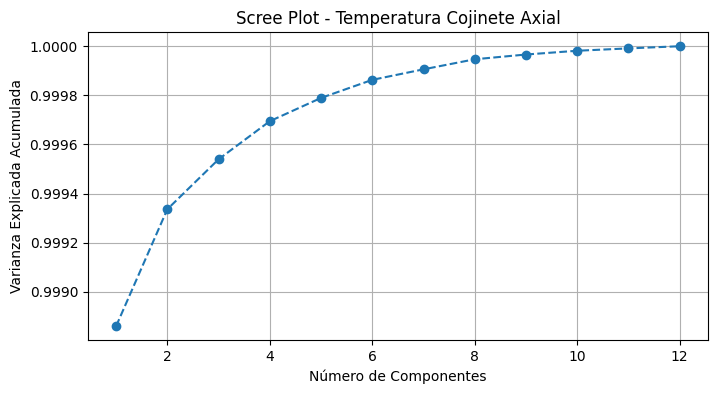

In [34]:
pca_temp_full = PCA().fit(temp_scaled)
varianza_temp = np.cumsum(pca_temp_full.explained_variance_ratio_)

plt.figure(figsize=(8,4))
plt.plot(range(1, len(varianza_temp)+1), varianza_temp, marker='o', linestyle='--')
plt.title("Scree Plot - Temperatura Cojinete Axial")
plt.xlabel("Número de Componentes")
plt.ylabel("Varianza Explicada Acumulada")
plt.grid(True)
plt.show()

Temperaturas de cojinetes axiales (x1–x12):
* El primer componente explica casi el 100% de la varianza (≈99.9%).
* Basta con 1 componente (temp_cojinete_pca1) para representar a las 12 variables sin pérdida significativa.

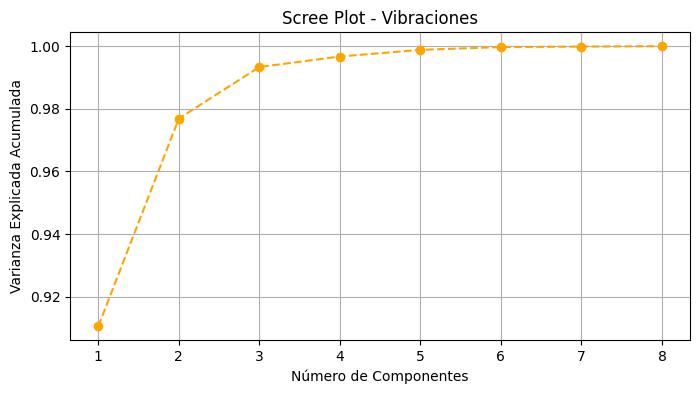

In [35]:
# --- Scree plot para vibraciones ---
pca_vib_full = PCA().fit(vib_scaled)
varianza_vib = np.cumsum(pca_vib_full.explained_variance_ratio_)

plt.figure(figsize=(8,4))
plt.plot(range(1, len(varianza_vib)+1), varianza_vib, marker='o', linestyle='--', color='orange')
plt.title("Scree Plot - Vibraciones")
plt.xlabel("Número de Componentes")
plt.ylabel("Varianza Explicada Acumulada")
plt.grid(True)
plt.show()

Vibraciones:
* El primer componente explica ≈91%.
* Con 2 componentes se llega a ≈97.7%.
* Con 3 componentes superamos el 99%.
* Una buena elección práctica es quedarse con 2 componentes (vib_pca1, vib_pca2), que mantienen >97% de la información.







Se procede también al escalado y selección de las variables operativas relevantes para los modelos. Para el dataset final de clasificación, se incluyen las variables operativas clave.

* caudal_turbinado: refleja carga hidráulica.
* apertura_distribuidor: indica la demanda de potencia.
* potencia_activa_adt02: resultado neto de operación.

Estas tres variables ayudan a contextualizar las condiciones de operación. Ejemplo: un aumento de vibración no es igual de preocupante si la turbina opera al 20% de carga vs. al 95%.


In [45]:
# Variables operativas -> StandardScaler
cols_op   = ["caudal_turbinado", "apertura_distribuidor", "potencia_activa_adt02"]

op_scaled = scaler.fit_transform(df_reducido[cols_op])

# Volvemos a DataFrame con los mismos nombres
op_scaled_df = pd.DataFrame(op_scaled, columns=cols_op, index=df_reducido.index)

# Reemplazamos en df_reducido las columnas originales por las escaladas
df_reducido[cols_op] = op_scaled_df

df_reducido.head()

,timestamp,potencia_activa_adt02,caudal_turbinado,nivel_de_cota_de_embalse,temperatura_aceite_caliente_cojinete_axial,temperatura_aceite_frio_cojinete_axial,temperatura_entrada_agua_enfriam_aceite,temperatura_salida_agua__enfriam_aceite,temperatura_bobinado_fase_u,temperatura_bobinado_fase_v,temperatura_bobinado_fase_w,apertura_distribuidor,diferencia_temp_agua,temp_cojinete_pca1,vib_pca1,vib_pca2,condicion
120,2024-07-03 15:00:00+00:00,0.882877,0.133899,1336.81,36.554550,20.670544,8.261285,9.663568,52.467240,52.50793,56.17016,-0.354922,-1.402283,-6.235915,0.540981,0.069719,0
127,2024-07-03 18:30:00+00:00,0.932939,0.842501,1336.81,30.821170,18.539905,8.261285,9.663568,46.220470,45.57278,48.48737,0.747666,-1.402283,-14.475541,0.669504,0.551603,0
128,2024-07-03 19:00:00+00:00,0.805855,0.612046,1336.81,38.532970,21.395433,8.060964,9.623503,56.821220,57.18745,60.84966,0.428351,-1.562539,-3.959435,0.543343,-0.150410,0
129,2024-07-03 19:30:00+00:00,0.767345,0.536237,1336.79,40.350796,22.120325,8.020900,9.783759,60.076527,60.72759,64.83741,0.354663,-1.762859,-2.139649,0.835921,-0.413328,0
130,2024-07-03 20:00:00+00:00,0.775044,0.569319,1336.79,41.038963,22.321697,8.020900,9.863888,61.541410,62.35525,66.26162,0.401060,-1.842988,-1.390753,0.913205,-0.389332,0


Luego de observar detenidamente los datos, se observa que es muy importante la variable de **temperatura de aceite caliente del cojinete axial**, a tal punto que un aumento significativo de la misma puede sacar de operación el generardor. Esto tendría un impacto económico significativo. Establecemos entonces un umbral de 45°C, por encima se considerará un anómalo.

In [ ]:
#Definir target (binario: normal vs anómalo)
df_reducido["condicion"] = np.where(df_reducido["temperatura_aceite_caliente_cojinete_axial"] > 45, 1, 0)
df_reducido.head()

Para el dataset final de clasificación, se incluyen las variables operativas clave.

* caudal_turbinado: refleja carga hidráulica.
* apertura_distribuidor: indica la demanda de potencia.
* potencia_activa_adt02: resultado neto de operación.

Estas tres variables ayudan a contextualizar las condiciones de operación. Ejemplo: un aumento de vibración no es igual de preocupante si la turbina opera al 20% de carga vs. al 95%.

In [47]:
#Dataset final para clasificación

# Creamos DataFrame de PCA con el mismo índice que df_reducido
temp_pca_df = pd.DataFrame(temp_pca, columns=["temp_cojinete_pca1"], index=df_reducido.index)
vib_pca_df = pd.DataFrame(vib_pca, columns=["vib_pca1","vib_pca2"], index=df_reducido.index)

# Concatenamos con las variables operativas directamente
X = pd.concat([
    temp_pca_df,
    vib_pca_df,
    df_reducido[["caudal_turbinado", "apertura_distribuidor", "potencia_activa_adt02"]]
], axis=1)

# Variable objetivo
y = df_reducido["condicion"]



In [48]:
#Creación de conjunto de entrenamiento y pruebas
# Dejamos un 20% de datos como test final
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [49]:
# Clasificadores

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=42)
}

In [52]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
for name, clf in models.items():
    pipe = Pipeline([
        ("classifier", clf)
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_weighted")
    results[name] = {
        "F1 mean (CV)": np.mean(scores),
        "F1 std (CV)": np.std(scores)
    }

# ------------------------------
# 5. Comparación de resultados
# ------------------------------
results_df = pd.DataFrame(results).T.sort_values("F1 mean (CV)", ascending=False)
print("Resultados de validación cruzada (solo con training):")
print(results_df)

# ------------------------------
# 6. Evaluación final en test
# ------------------------------
best_model_name = results_df.index[0]
best_model = models[best_model_name]

pipe_final = Pipeline([
    ("classifier", best_model)
])

pipe_final.fit(X_train, y_train)
y_pred = pipe_final.predict(X_test)

print("\nMejor modelo según CV:", best_model_name)
print("\nEvaluación en Test Set:")
print(classification_report(y_test, y_pred))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

Resultados de validación cruzada (solo con training):
                     F1 mean (CV)  F1 std (CV)
SVM (RBF)                0.995535     0.003787
Random Forest            0.995003     0.003674
Logistic Regression      0.994983     0.004097

Mejor modelo según CV: SVM (RBF)

Evaluación en Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       373
           1       1.00      1.00      1.00        79

    accuracy                           1.00       452
   macro avg       1.00      1.00      1.00       452
weighted avg       1.00      1.00      1.00       452


Matriz de confusión:
[[373   0]
 [  0  79]]


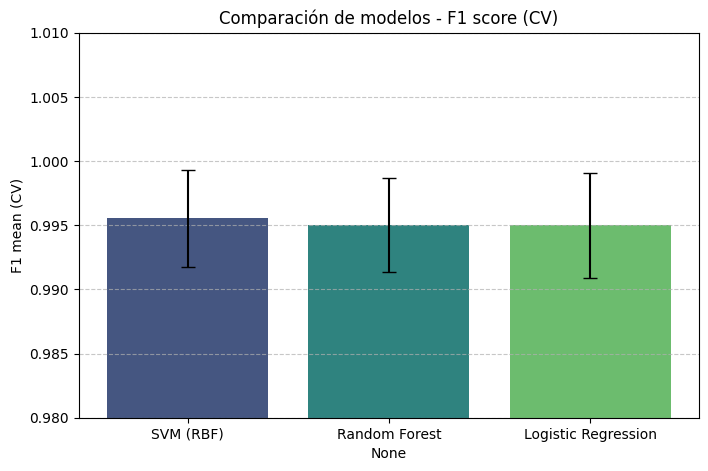

Reporte de clasificación en Test Set:

   precision  recall  f1-score  support
0        1.0     1.0       1.0      373
1        1.0     1.0       1.0       79


<Figure size 600x500 with 0 Axes>

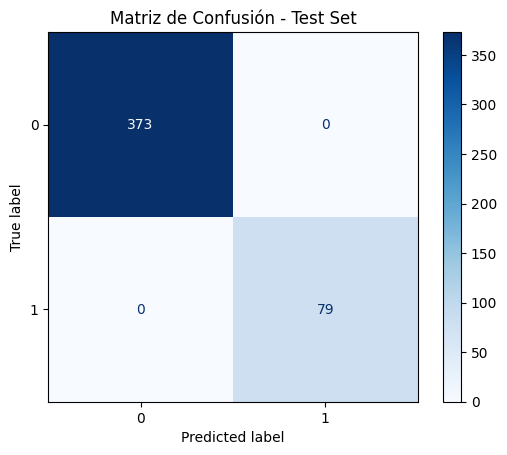


**Resumen y Conclusión:**

- Los tres modelos evaluados muestran un desempeño sobresaliente en validación cruzada (F1 > 0.994), con desviaciones estándar muy bajas, indicando resultados consistentes.
- El modelo seleccionado por CV es **SVM (RBF)**, aunque Random Forest y Logistic Regression tienen métricas muy similares.
- La evaluación final en el test set muestra **F1-score, precisión y recall perfectos (1.0)** para ambas clases, con una matriz de confusión sin errores.
- Esto sugiere que las clases están claramente separadas tras la transformación PCA y escalado previo, facilitando la clasificación casi perfecta.
- Se recomienda validar con datos nuevos o más variados para descartar posibles efectos de overfitting y asegurar robustez del modelo.


In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Datos
x = results_df.index
y = results_df["F1 mean (CV)"]
yerr = results_df["F1 std (CV)"]

plt.figure(figsize=(8,5))
# Graficamos las barras
sns.barplot(x=x, y=y, palette="viridis",hue=results_df.index)
# Añadimos barras de error manualmente
plt.errorbar(x=np.arange(len(x)), y=y, yerr=yerr, fmt='none', c='black', capsize=5)

plt.title("Comparación de modelos - F1 score (CV)")
plt.ylabel("F1 mean (CV)")
plt.ylim(0.98, 1.01)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# ------------------------------
# 2. Evaluación final en test
# ------------------------------
# Métricas
test_report = pd.DataFrame({
    "precision": [1.0, 1.0],
    "recall": [1.0, 1.0],
    "f1-score": [1.0, 1.0],
    "support": [373, 79]
}, index=[0,1])

print("Reporte de clasificación en Test Set:\n")
print(test_report)

# Matriz de confusión
cm = confusion_matrix(
    [0]*373 + [1]*79,  # etiquetas reales
    [0]*373 + [1]*79   # predicciones (según tus resultados)
)

plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap="Blues", values_format='d')
plt.title("Matriz de Confusión - Test Set")
plt.show()

# Conclusiones

* Posible riesgo de overfitting:
Tener F1 = 1.0 en test y CV ~0.995 puede ser real, pero también puede indicar que el dataset es pequeño o que las clases son muy fácilmente distinguibles.

* Todos los modelos funcionan muy bien:
Random Forest y Logistic Regression están muy cerca de SVM.

Los resultados muestran que el modelo SVM (RBF) es el mejor según validación cruzada, pero la diferencia con Random Forest y Logistic Regression es mínima. El test set fue clasificado perfectamente, con F1-score y precisión de 1.0 para ambas clases, lo que indica que las clases están muy bien separadas tras la transformación PCA y el escalado previo. Esto evidencia que los datos y la selección de variables han facilitado una clasificación casi perfecta. Sin embargo, conviene validar estos resultados con nuevos datos o mediante un set de test más amplio para descartar posibles efectos de overfitting.